# Phase-4:SAM Footprint Extraction on Real Surat Tiles

 SAM setup,filter function, and the batch loop across all 5 tiles



## 1. Install dependencies

In [ ]:
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q opencv-python matplotlib numpy
print('Installed.')

  Preparing metadata (setup.py) ... done
Installed.


## 2. Download SAM model weights
This is the ~2.5GB `vit_h` checkpoint -- let it finish, don't interrupt.

In [ ]:
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
print('Downloaded SAM weights.')

Downloaded SAM weights.


## 3. Load SAM and build the automatic mask generator
Using finer sampling settings than the default -- catches smaller/thinner rooftops that default settings can miss.

In [ ]:
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

sam_checkpoint = 'sam_vit_h_4b8939.pth'
model_type = 'vit_h'

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

mask_generator_fine = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=48,           # up from default 32 -- catches smaller/thinner roofs
    pred_iou_thresh=0.86,
    stability_score_thresh=0.90,
    min_mask_region_area=100      # drop tiny noise masks early
)

print('SAM loaded and mask generator ready.')

Using device: cuda
SAM loaded and mask generator ready.


## 4.rooftop filter function
Filters out ground/road/vegetation blobs based on size, shape, and color.

In [ ]:
def filter_rooftop_masks(masks, image,
                           min_area=100, max_area=12000,
                           max_aspect_ratio=4.0,
                           max_green_fraction=0.4):   # slightly relaxed from 0.35
    """Keep masks that look like rooftops: right size, roughly compact shape, not mostly green."""
    keep = []
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    for m in masks:
        seg = m['segmentation']
        seg = np.asarray(seg, dtype=bool)
        area = m['area']

        # 1. Size filter
        if area < min_area or area > max_area:
            continue

        # 2. Shape filter -- drop long thin strips (roads)
        x, y, w, h = m['bbox']
        aspect_ratio = max(w, h) / max(min(w, h), 1)
        if aspect_ratio > max_aspect_ratio:
            continue

        # 3. Color filter -- drop mostly-vegetation masks only
        mask_pixels_hsv = hsv[seg]
        green_lower = np.array([35, 40, 40])
        green_upper = np.array([85, 255, 255])
        green_pixels = np.all((mask_pixels_hsv >= green_lower) & (mask_pixels_hsv <= green_upper), axis=1)
        green_fraction = green_pixels.sum() / len(mask_pixels_hsv)
        if green_fraction > max_green_fraction:
            continue

        keep.append(m)

    return keep

print('Filter reverted to size + shape + green only (no texture, no dedup).')

Filter reverted to size + shape + green only (no texture, no dedup).


## 5. Visualization helper
Draws all masks as random-colored overlays on the image.

In [ ]:
import matplotlib.pyplot as plt

def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)
    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask
    ax.imshow(img)

print('Visualization helper ready.')

Visualization helper ready.


## 6. Upload your 5 tiles + tile_registry.json
Select all 6 files together in the upload dialog: `tile_17.png`, `tile_18.png`, `tile_19.png`, `tile_21.png`, `tile_22.png`, `tile_registry.json`

In [ ]:
from google.colab import files
import json

uploaded = files.upload()

with open('tile_registry.json') as f:
    tile_registry = json.load(f)

print('Tiles registered:', list(tile_registry.keys()))

Saving Screenshot 2026-08-22 175234.png to Screenshot 2026-08-22 175234.png
Saving Screenshot 2026-08-22 175320.png to Screenshot 2026-08-22 175320.png
Saving Screenshot 2026-08-22 175411.png to Screenshot 2026-08-22 175411.png
Saving Screenshot 2026-08-22 175504.png to Screenshot 2026-08-22 175504.png
Saving Screenshot 2026-08-22 175546.png to Screenshot 2026-08-22 175546.png
Saving tile_registry.json to tile_registry.json
Tiles registered: ['tile_17', 'tile_18', 'tile_19', 'tile_21', 'tile_22']


In [ ]:
import os
print(sorted(os.listdir('.')))

['.config', 'Screenshot 2026-08-22 175234.png', 'Screenshot 2026-08-22 175320.png', 'Screenshot 2026-08-22 175411.png', 'Screenshot 2026-08-22 175504.png', 'Screenshot 2026-08-22 175546.png', 'sam_vit_h_4b8939.pth', 'sample_data', 'tile_registry.json']


In [ ]:
filename_map = {
    'tile_17': 'Screenshot 2026-08-22 175234.png',
    'tile_18': 'Screenshot 2026-08-22 175320.png',
    'tile_19': 'Screenshot 2026-08-22 175411.png',
    'tile_21': 'Screenshot 2026-08-22 175504.png',
    'tile_22': 'Screenshot 2026-08-22 175546.png',
}

## 7. Run SAM + filter on every tile
This is the actual batch processing step -- may take a few minutes total since each tile runs SAM separately.

In [ ]:
import cv2
import numpy as np
all_results = {}


for tile_id in tile_registry.keys():
    filename = filename_map[tile_id]
    print(f'Processing {filename}...')

    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    masks = mask_generator_fine.generate(img)
    filtered = filter_rooftop_masks(masks, img)

    all_results[tile_id] = {'image': img, 'masks': filtered}
    print(f'  {len(masks)} total -> {len(filtered)} after filtering')

print(f'\nDone. Processed {len(all_results)} tiles.')

Processing Screenshot 2026-08-22 175234.png...
  532 total -> 310 after filtering
Processing Screenshot 2026-08-22 175320.png...
  461 total -> 188 after filtering
Processing Screenshot 2026-08-22 175411.png...
  432 total -> 105 after filtering
Processing Screenshot 2026-08-22 175504.png...
  563 total -> 228 after filtering
Processing Screenshot 2026-08-22 175546.png...
  562 total -> 274 after filtering

Done. Processed 5 tiles.


Polygon formation

In [ ]:
import geopandas as gpd
from shapely.geometry import Polygon
from rasterio.features import shapes

def pixel_to_latlon(px, py, img_width, img_height, top_left, bottom_right):
    lat = top_left[0] + (py / img_height) * (bottom_right[0] - top_left[0])
    lon = top_left[1] + (px / img_width) * (bottom_right[1] - top_left[1])
    return lat, lon

all_footprints = []
building_id = 1

for tile_id, data in all_results.items():
    img = data['image']
    img_h, img_w = img.shape[:2]
    top_left = tile_registry[tile_id]['top_left']
    bottom_right = tile_registry[tile_id]['bottom_right']

    for mask_dict in data['masks']:
        seg = mask_dict['segmentation'].astype('uint8')
        for geom, val in shapes(seg):
            if val == 1:
                pixel_coords = geom['coordinates'][0]
                latlon_coords = []
                for x, y in pixel_coords:
                    lat, lon = pixel_to_latlon(x, y, img_w, img_h, top_left, bottom_right)
                    latlon_coords.append((lon, lat))  # GeoJSON order: (lon, lat)

                poly = Polygon(latlon_coords)
                if poly.is_valid and poly.area > 0:
                    all_footprints.append({
                        'building_id': f'SRT-{building_id:04d}',
                        'source_tile': tile_id,
                        'geometry': poly
                    })
                    building_id += 1

footprints_gdf = gpd.GeoDataFrame(all_footprints, crs='EPSG:4326')
footprints_gdf.to_file('footprints.geojson', driver='GeoJSON')
print(f'Saved {len(footprints_gdf)} building footprints')
print('Coordinate bounds:', footprints_gdf.total_bounds)

from google.colab import files
files.download('footprints.geojson')

Saved 1132 building footprints
Coordinate bounds: [72.776518 21.161507 72.793918 21.164207]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

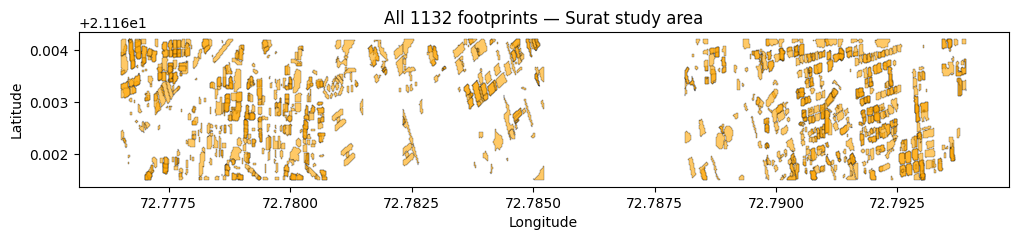

    building_id source_tile
944    SRT-0945     tile_22
658    SRT-0659     tile_21
770    SRT-0771     tile_21
930    SRT-0931     tile_22
769    SRT-0770     tile_21
931    SRT-0932     tile_22
261    SRT-0262     tile_17
44     SRT-0045     tile_17
544    SRT-0545     tile_19
879    SRT-0880     tile_22
183    SRT-0184     tile_17
664    SRT-0665     tile_21
164    SRT-0165     tile_17
424    SRT-0425     tile_18
550    SRT-0551     tile_19


In [ ]:
import matplotlib.pyplot as plt

footprints_gdf.plot(figsize=(12,10), edgecolor='black', linewidth=0.3, facecolor='orange', alpha=0.6)
plt.title(f'All {len(footprints_gdf)} footprints — Surat study area')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

sample = footprints_gdf.sample(min(15, len(footprints_gdf)))
print(sample[['building_id', 'source_tile']])

## 8. Visualize all 5 tiles side by side

In [ ]:
import matplotlib.pyplot as plt

n = len(all_results)

# Create 1 row with n columns
fig, axes = plt.subplots(
    1,
    n,
    figsize=(10 * n, 10),
    dpi=200,
    squeeze=False
)

axes = axes[0]

for ax, (tile_id, data) in zip(axes, all_results.items()):

    ax.imshow(data['image'])

    plt.sca(ax)
    show_anns(data['masks'])

    ax.set_title(
        f"{tile_id}: {len(data['masks'])} roofs",
        fontsize=16
    )

    ax.axis('off')

plt.tight_layout()

# Save high-resolution horizontal image
plt.savefig(
    "horizontal_roof_results.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1
)

plt.show()

## 9. Total rooftop count

In [ ]:
total_roofs = sum(len(d['masks']) for d in all_results.values())
print(f'Total candidate rooftops across all {len(all_results)} tiles: {total_roofs}')

for tile_id, data in all_results.items():
    print(f'  {tile_id}: {len(data["masks"])} roofs')

---
## Done? Checkpoint

You should now have:
- `all_results` -- a dict with every tile's image + filtered rooftop masks
- A visual grid confirming the masks look reasonable
- A total rooftop count across your whole study area

**Save your session:** File -> Download -> Download .ipynb, or File -> Save a copy in Drive, so `all_results` and this whole setup are easy to pick back up next time.

**Next up (Task P4.2):** convert `all_results`'s pixel masks into real lat/lon polygons using each tile's `top_left`/`bottom_right` from `tile_registry`, producing your final `footprints.geojson`.